In [13]:
import os
import struct
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm



# Fashion Dataset

In [14]:


class FashionMNISTDataset(Dataset):
    def __init__(self, images_path, labels_path):
        self.images = self.read_images(images_path)
        self.labels = self.read_labels(labels_path)

    def read_images(self, path):
        with open(path, "rb") as f:
            magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
            images = np.frombuffer(f.read(), dtype=np.uint8)

        images = images.reshape(num_images, rows, cols)

        # Normalize to [0, 1]
        images = images.astype(np.float32) / 255.0

        # Shape: [N, 1, 28, 28]
        images = np.expand_dims(images, axis=1)

        return torch.tensor(images, dtype=torch.float32)

    def read_labels(self, path):
        with open(path, "rb") as f:
            magic, num_labels = struct.unpack(">II", f.read(8))
            labels = np.frombuffer(f.read(), dtype=np.uint8)

        return torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]



# Model

In [15]:
class FashionCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(FashionCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # [B, 32, 28, 28]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # [B, 32, 14, 14]

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # [B, 64, 14, 14]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # [B, 64, 7, 7]
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [16]:
import matplotlib.pyplot as plt
def visualize_predictions(model, loader, class_names, device, num_images=12):
    """
    Visualisasi beberapa hasil prediksi model.
    Menampilkan:
    - gambar
    - label asli
    - label prediksi
    - confidence score
    """

    model.eval()

    images_shown = 0

    plt.figure(figsize=(15, 8))

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).long()

            outputs = model(images)

            probabilities = F.softmax(outputs, dim=1)
            confidences, preds = torch.max(probabilities, dim=1)

            images = images.cpu()
            labels = labels.cpu()
            preds = preds.cpu()
            confidences = confidences.cpu()

            batch_size = images.size(0)

            for i in range(batch_size):
                if images_shown >= num_images:
                    break

                plt.subplot(3, 4, images_shown + 1)

                image = images[i]

                if image.shape[0] == 1:
                    image = image.squeeze(0)

                plt.imshow(image, cmap="gray")
                plt.axis("off")

                true_label = class_names[labels[i].item()]
                pred_label = class_names[preds[i].item()]
                confidence = confidences[i].item()

                color = "green" if labels[i] == preds[i] else "red"

                plt.title(
                    f"True: {true_label}\n"
                    f"Pred: {pred_label}\n"
                    f"Conf: {confidence:.2f}",
                    color=color,
                    fontsize=10
                )

                images_shown += 1

            if images_shown >= num_images:
                break

    plt.tight_layout()
    plt.show()

# Train & Evaluate

In [17]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# --- 1. Hyperparameters ---
batch_size = 100
learning_rate = 0.001
num_epochs = 10

# --- 2. Set Device ---
# Mengecek apakah ada GPU Nvidia (CUDA) di laptop ASUS TUF lu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device yang digunakan:", device)

# --- 3. Preprocessing & Transformasi Gambar ---
# Mengubah gambar FashionMNIST menjadi Tensor dan melakukan normalisasi standar
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# --- 4. Otomatis Download Dataset Resmi (Solusi bypass path Kaggle) ---
path_lokal = r"C:\FashionMNIST_Data"

train_dataset = torchvision.datasets.FashionMNIST(
    root=path_lokal, 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root=path_lokal, 
    train=False, 
    download=True, 
    transform=transform
)

# --- 5. Setup Data Loader ---
# Catatan: num_workers diubah ke 0 agar aman dan tidak crash di OS Windows
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("[INFO] Dataset sukses dimuat! Siap lanjut ke training model.")

Device yang digunakan: cpu


100%|██████████| 26.4M/26.4M [01:06<00:00, 399kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 140kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.51MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.16MB/s]

[INFO] Dataset sukses dimuat! Siap lanjut ke training model.


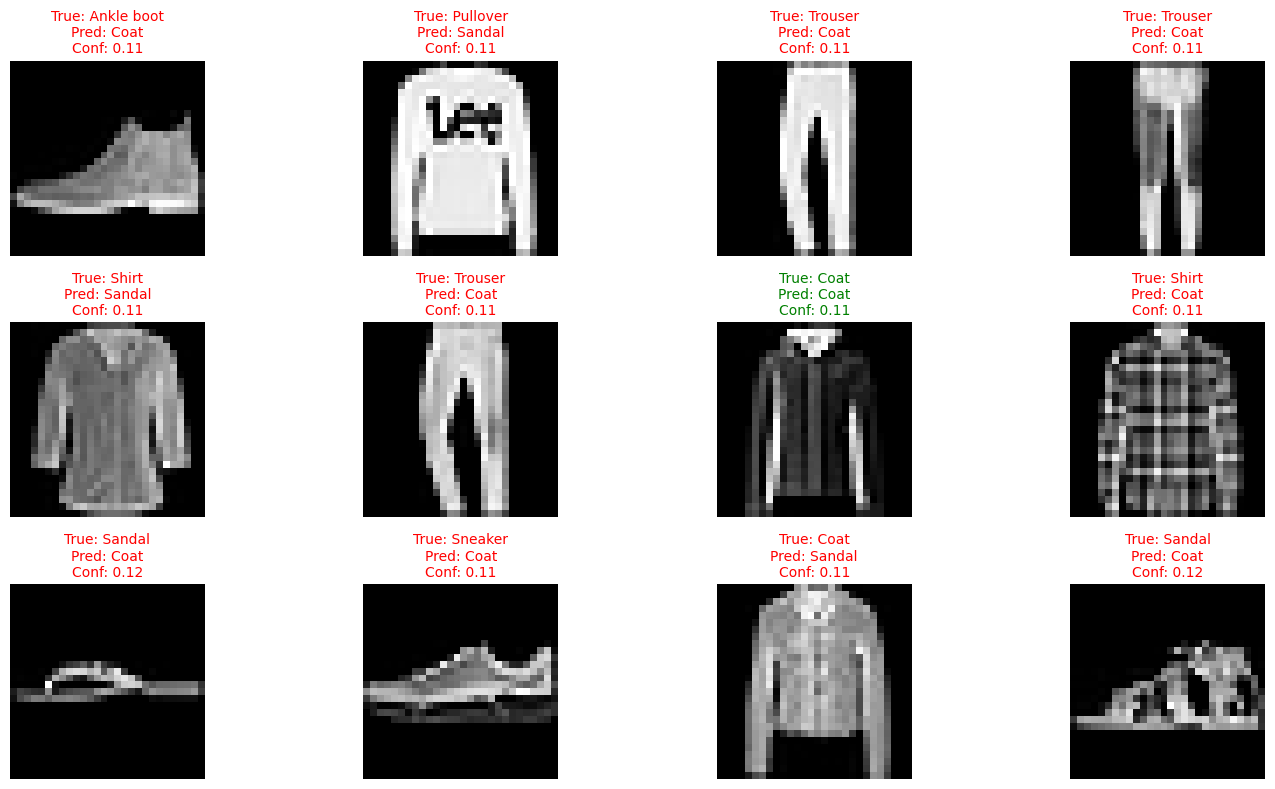

In [29]:
import torch.nn.functional as F

# 1. Definisikan nama-nama kelas Fashion MNIST (INI YANG HILANG)
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# 2. Definisikan device & model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FashionCNN(num_classes=num_classes).to(device)

# 3. Set model ke mode evaluasi (Skenario A - tanpa load file .pth dari Kaggle)
model.eval()

# 4. Panggil fungsi visualisasi
visualize_predictions(
    model=model,
    loader=test_loader,
    class_names=class_names, # Sekarang variabel ini sudah aman
    device=device,
    num_images=12
)